<a href="https://colab.research.google.com/github/22f2000792/MLP-prac/blob/main/Copy_of_Practice_Oppe_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing

### Access the dataset from here :

https://drive.google.com/file/d/1XztaPmhMMhBoEp7XuyDGS5Il_kLUlEEl/view?usp=sharing

### Notes:
* This exam consists of a **Regression** problem.  
* The **target** feature is '**cltv**'.
* **Random state** should be taken as **42** wherever applicable.

# Metadata

1. **id**-Unique identifier of a customer  
2. **gender**-Gender of the customer   
3. **area**-Area of the customer   
4. **qualification**-Highest Qualification of the customer  
5. **income**-Income earned in a year (in rupees).   
6. **marital_status**- 0:Single, 1: Married
7. **vintage**-No. of years since the first policy date.  
8. **claim_amount**-Total Amount Claimed by the customer (in rupees)
9. **num_policies**-Total no. of policies issued by the customer
10. **policy**-Active policy of the customer
11. **type_of_policy**-Type of active policy
12. **cltv**- Customer life time value. It is the total amount of money a customer is expected to spend with your business, or on your products, during the lifetime of an average business relationship. **[TARGET]**

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/drive/MyDrive/Dataset/V1.csv')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Q.2 [Marks: 2] How many total number of features (excluding target variable) are there in the dataset?
Options

A) 1000

B) 11

C) 12

D) 10

`Ans: 11 input features`

In [3]:
# Solution
len(df.columns)-1

11

### Q.3 [Marks: 2] What are the unique values of feature `Types of Policy` in the dataset?

A) ['Bronze', 'Gold']

B) ['Gold', 'Silver']

C) ['Platinum', 'Gold', 'Silver', 'Bronze]

D) ['Platinum', 'Gold', 'Silver']


`Ans: ['Platinum', 'Gold', 'Silver'](D)`

In [4]:
# Solution
df['type_of_policy'].unique()

array(['Platinum', 'Gold', 'Silver'], dtype=object)

### Q.4 [Marks: 3] Which of the following columns have categorical data?[MSQ]

A) income

B) id

C) area

D) claim_amount

E) qualification

`Ans: area (C), qualification (E)`

In [5]:
# Solution
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6257 entries, 0 to 6256
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6257 non-null   int64  
 1   gender          6257 non-null   object 
 2   area            5873 non-null   object 
 3   qualification   6257 non-null   object 
 4   income          5856 non-null   float64
 5   marital_status  6257 non-null   int64  
 6   vintage         6257 non-null   int64  
 7   claim_amount    5897 non-null   float64
 8   num_policies    6257 non-null   object 
 9   policy          5885 non-null   object 
 10  type_of_policy  6257 non-null   object 
 11  cltv            6257 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 586.7+ KB


### Q.5 [Marks: 4] Plot the `heatmap` and mark the pair which has the highest positive correlation value. [MCQ]

A) claim_amount & income

B) income & cltv

C) vintage & income.

D) claim_amount & cltv.

`Ans: claim_amount and cltv (D)`

In [6]:
# Solution
import matplotlib.pyplot as plt
import seaborn as sns
cor=df.select_dtypes(include=np.number)
corr_data=cor.corr()
corr_data

,id,income,marital_status,vintage,claim_amount,cltv
id,1.000000,-0.005279,-0.008367,-0.014001,-0.008671,-0.021593
income,-0.005279,1.000000,-0.009225,-0.009673,-0.129808,-0.037748
marital_status,-0.008367,-0.009225,1.000000,-0.010106,-0.134100,-0.082076
vintage,-0.014001,-0.009673,-0.010106,1.000000,-0.001643,0.034253
claim_amount,-0.008671,-0.129808,-0.134100,-0.001643,1.000000,0.189348
cltv,-0.021593,-0.037748,-0.082076,0.034253,0.189348,1.000000


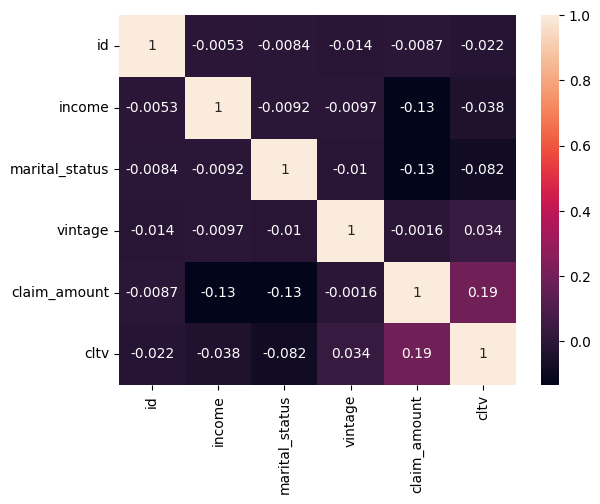

In [7]:
sns.heatmap(corr_data,annot=True)
plt.show()

### Q.6 [Marks: 2] Which of the following features have `missing` values?[MSQ]

Options:

A) gender

B) area

C) qualification

D) income

E) claim_amount

F) policy

`Ans: area(B), income(D), claim_amount(E), policy(F)`

In [8]:
# Solution
df.isna().sum()

,0
id,0
gender,0
area,384
qualification,0
income,401
marital_status,0
vintage,0
claim_amount,360
num_policies,0
policy,372


### Q.7 [Marks: 4] Break the dataset into features(`X`) and label (`y`), where the column `cltv` goes to `y` and the rest of the columns go to `X`. Enter the avg value of `cltv` column? [NAT]


`Ans: 97788.08`

In [9]:
# Solution
feature=df.drop('cltv',axis=1)
label=df['cltv'].copy()
label.mean()

np.float64(97788.08438548826)

### Q.8 [Marks : 3] Split the dataset into training and test dataset using `train_test_split` into `70:30` ratio while keeping random_state =42. What is the shape of the training set (X_train) ? [MCQ]


A) (4379, 11)

B) (4392, 13)

C) (4340, 11)

D) (4379, 15)

`Ans: (4379, 11) (A)`

In [10]:
# Solution
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(feature,label,random_state=42,test_size=0.3)
print(X_train.shape)

(4379, 11)


### Q.9 [Marks: 2] Drop(remove) `id` column from train and test data because it is not useful in model training. Now how many feature columns are remaining in the training dataset? [NAT]

`Ans: 10 features`

In [11]:
# Solution
X_train.head(3)

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
1292,9728,Female,Urban,High School,8.44,0,8,9538.0,1,A,Platinum
70,51597,Female,Urban,High School,78.75,0,3,0.0,More than 1,A,Platinum
5453,82031,Female,Rural,High School,5.66,1,5,2555.0,More than 1,C,Platinum


In [12]:
X_train=X_train.drop('id',axis=1)
X_test=X_test.drop('id',axis=1)
len(X_train.columns)

10

### Q.10 [Marks: 2] Compute and write median of the `income` column of X_train while ignoring the missing values. Replace all NaN values in the income column of X_train and X_test by the median  computed from the X_train (upto two decimal). [NAT].

`Ans: 7.04`

In [13]:
# Solution
median=X_train['income'].median()
print(median)
X_train['income']=X_train['income'].fillna(median)
X_test['income']=X_test['income'].fillna(median)

7.04


### Q.11 [Marks: 2] Which is the most frequent value in the `policy` column of X_train? Replace all NaN value in `policy` column of X_train and X_test by most frequent value in X_train [MCQ]

A) 'A'

B) 'B'

C) 'C'

D) None of the above

`Ans: A`

In [14]:

# Solution
policy=X_train['policy'].mode()[0]
X_train['policy']=X_train['policy'].fillna(policy)

X_test['policy']=X_test['policy'].fillna(policy)
#X_train.describe(exclude=np.number)
# or
X_train['policy'].value_counts()

,count
policy,
A,2827
B,1160
C,392


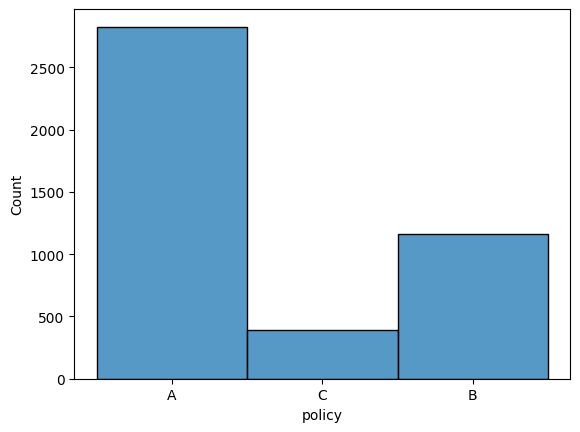

In [15]:
sns.histplot(X_train['policy'])
plt.show()

### Q.12 [Marks: 2] Which is the most frequent value in the `area` column of X_train? Replace all NaN value in `area` column of X_train and X_test by most frequent value from X_train [MCQ]

A) 'Urban'

B) 'Rural'

C) 'Semi-Urban'

D) None of the above

`Ans: Urban (A)`

In [16]:
# Solution
area_mode=X_train['area'].mode()[0]
X_train['area']=X_train['area'].fillna(area_mode)
X_test['area']=X_test['area'].fillna(area_mode)
print(X_train['area'].isna().sum())
# urban
df['area'].value_counts()

0


,count
area,
Urban,4118
Rural,1755


### Q.13 [Marks: 2] Replace all NaN value in claim_amount column of X_train and X_test by 0 (Zero). After Replacing NAN values from claim_amount column what is the standard deviation of claim_amount column in X_train. (correct upto two decimal places) [NAT]

`Ans: 3358.66`

In [17]:
# Solution
X_train['claim_amount']=X_train['claim_amount'].fillna(0)
X_test['claim_amount']=X_test['claim_amount'].fillna(0)
np.std(X_train['claim_amount'])

3358.272390023111

In [18]:
X_train['claim_amount'].isna().sum()

np.int64(0)

### Q.14 [Marks: 4] Apply `MinMaxScaler` on `income` column of X_train. Compute and write median of `income` column? (correct Upto 2 decimal)[NAT]

`Ans: 0.07`

In [19]:
# Solution
from sklearn.preprocessing import  MinMaxScaler
mm=MinMaxScaler()
X_train['income']=mm.fit_transform(X_train[['income']])
X_train['income'].median()

0.07004709890770619

## Apply preprocessing on features of X_train and X_test dataset.

### For Categorical Features

* Apply OneHotEncoding from `sklearn` library on all categorical features(object columns). Do Encoding in the order of following list

  `Categorical Features = ['gender', 'area','qualification','marital_status', 'num_policies', 'policy', 'type_of_policy']`

Lets call the transformed caterical feature matrix $X1$

### For Numerical Features

- apply MinMaxScaler and transform the dataset. Do scaling in the order of following list:

  `Numerical Features =  [ 'income', 'vintage', 'claim_amount' ]`


  - Lets call the transformed numerical feature matrix $X2$

### **Concatenate**(One Hot Encoded Features, Scaled Numerical Features)

After combining transformed categorical feature($X_1$) matrix and transformed numerical feature matrix ($X_2$) (side by side in that order), the output will be $X=[X_1 X_2]$

### Hints
* Apply ColumnTransformer to encode categorical columns and scaling on numerical columns with required preprocessor

* Another way is to separately encode all categorical columns and scale numerical columns and do concatenate (`h-stack`) both. keep categorical columns in front of numerical while concatenating.


* The transformed (as desribed by above steps) X_train and X_test, should be considered as X_train and X_test henceforth.


In [20]:
# Solution
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import  Pipeline
Categorical_Features = ['gender', 'area','qualification','marital_status', 'num_policies', 'policy', 'type_of_policy']
Numerical_Features = [ 'income', 'vintage', 'claim_amount' ]
cat_pipe=Pipeline([
    ('cat_data',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])
num_pipe=Pipeline([
    ('num_data',MinMaxScaler())
])

In [21]:
transformer=ColumnTransformer([
    ('cat',cat_pipe,Categorical_Features),
    ('num',num_pipe,Numerical_Features)
],remainder='passthrough').set_output(transform='pandas')
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 Pipeline(steps=[('cat_data',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'area', 'qualification',
                                  'marital_status', 'num_policies', 'policy',
                                  'type_of_policy']),
                                ('num',
                                 Pipeline(steps=[('num_data', MinMaxScaler())]),
                                 ['income', 'vintage', 'claim_amount'])])

In [22]:
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)
X_train.head()

,cat__gender_Female,cat__gender_Male,cat__area_Rural,cat__area_Urban,cat__qualification_Bachelor,cat__qualification_High School,cat__qualification_Others,cat__marital_status_0,cat__marital_status_1,cat__num_policies_1,cat__num_policies_More than 1,cat__policy_A,cat__policy_B,cat__policy_C,cat__type_of_policy_Gold,cat__type_of_policy_Platinum,cat__type_of_policy_Silver,num__income,num__vintage,num__claim_amount
1292,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.084077,1.000,0.360128
70,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.788656,0.375,0.000000
5453,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.056218,0.625,0.096470
1305,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.095501,0.125,0.407438
3207,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.822227,0.625,0.282764


## Q.15 [Marks: 10] How many features you will get after preprocessing? [MCQ]

[Options]

A) 13

B) 20

C) 25

D) 01

`Ans: 20 features (B)`

In [23]:
# Solution
len(X_train.columns)

20

In [24]:
X_train.columns

Index(['cat__gender_Female', 'cat__gender_Male', 'cat__area_Rural',
       'cat__area_Urban', 'cat__qualification_Bachelor',
       'cat__qualification_High School', 'cat__qualification_Others',
       'cat__marital_status_0', 'cat__marital_status_1', 'cat__num_policies_1',
       'cat__num_policies_More than 1', 'cat__policy_A', 'cat__policy_B',
       'cat__policy_C', 'cat__type_of_policy_Gold',
       'cat__type_of_policy_Platinum', 'cat__type_of_policy_Silver',
       'num__income', 'num__vintage', 'num__claim_amount'],
      dtype='object')

# Model Building

### Q.16 [Marks: 5] Apply `SequentialFeatureSelector` transformer with direction= 'forward' with `LinearRegression()` estimator and select 5 features by fitting to the X_train and y_train.

  `Use cv = KFold(n_splits=5,random_state=42,shuffle=True) in SequentialFeatureSelector.`

### Which of the following options represents the correct integer index of the selected features list?


A) [ 6  9 12 13 19]

B) [ 3  6  9 13 19]

C) [ 8  9 12 14 19]

D) [ 1  2  9 13 19]

E) [ 3  7 10 13 19]


`Ans: [6 9 12 13 19](A)`

In [25]:
# Solution
from sklearn.model_selection import KFold
cv = KFold(n_splits=5,random_state=42,shuffle=True)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
sq=SequentialFeatureSelector(lr,n_features_to_select=5,direction='forward',cv=cv)
sq.fit(X_train,y_train)


SequentialFeatureSelector(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                          estimator=LinearRegression(), n_features_to_select=5)

In [27]:
sq.get_support(indices=True)

array([ 6,  9, 12, 13, 19])

### Q.17 [Marks: 3] Apply `LinearRegression` on the trainig set(`X_train` and `y_train`). What is the `R2 score` on the test set(`X_test` and `y_test`). ( Upto 4 digits after decimal points) [NAT]


`ANS: 0.0821`

In [28]:
# Solution
from sklearn.metrics import r2_score
lr.fit(X_train,y_train)

LinearRegression()

In [31]:
lr_pred=lr.predict(X_test)
r2_score(y_test,lr_pred)

0.08207173714887239

### Q.18 [Marks: 6]Using the `LinearRegression` model, compute the `cross-validation scores` for `5 splits` on training data (X_train and y_train) using `cross_val_score`.Enter the maximum value of `𝑅2 score` ( Upto 4 digits after decimal points) obtained.[NAT]

`Use cv = KFold(n_splits=5,random_state=42,shuffle=True) in SequentialFeatureSelector.`

(**Hint**: By default cross_val_score uses LinearRegression's scoring metric, which is  𝑅2 score.)

`Ans: 0.1816 (Range: 0.1790-0.1845)`

In [34]:
# Solution
from sklearn.model_selection import cross_val_score
cv = KFold(n_splits=5,random_state=42,shuffle=True)
cs=cross_val_score(lr,X_train,y_train,cv=cv,n_jobs=-1,scoring='r2')
cs.max()

np.float64(0.18162637828684525)

### Q.19 [Marks: 5]Apply `Ridge` regression with **random_state=42** with default penalty value on training set(`X_train and y_train`) and calculate the 𝑅2 score on test_set (`X_test and y_test`). What is the correct score ( Upto 4 digits after decimal points)? [NAT]

`Ans: 0.0890`

In [36]:
# Solution
from sklearn.linear_model import Ridge
rg=Ridge(random_state=42)
rg.fit(X_train,y_train)


Ridge(random_state=42)

In [37]:
rg_pred=rg.predict(X_test)
r2_score(y_test,rg_pred)

0.0890150379157102

### Q.20: [Marks: 6] Apply `Lasso` regression with **random_state=42** and **regularization rate=0.1** on the training data(`X_train & y_train`). Enter the value of the intercept you got correctly upto 2 digits after decimal points . [NAT]

`Ans: 103168.82`

In [38]:
# Solution
from sklearn.linear_model import Lasso
ls=Lasso(random_state=42,alpha=0.1)
ls.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.107e+11, tolerance: 3.548e+09
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.1, random_state=42)

In [39]:
ls.intercept_

np.float64(103168.81823623728)

### Q.21 [Marks: 5] Fit SGDRegressor(`random_state=42`) estimator on the training data(`X_train & y_train`) and predict labels for test_data(`X_test`), lets call it as y_test_predict. The parameters are initialized with default values. Calculate and mark the correct mean_absolute_error value between y_test and y_test_predict from the given options. (Correct upto two decimals) [NAT]

`Ans: 53085.49`

In [ ]:
# Solution

### Q.22: [Marks: 6] Using SGDRegressor(random_state=42) as an estimator for exactly 10 iterations. Write the correct R2 score on test data  [NAT] (correct Upto 4 digits)

`Ans: 0.1359`

In [ ]:
# Solution

# (Common Instructions for Question 23 and 24)

### Create a pipeline Using PolynomialFeatures as transformer and Lasso as estimator. Use GridSearchCV with this created pipeline and following hyperparameter values on training data(X_train, y_train) to fit the model .
```
1. Keep polynomial degree as : [1, 2]
2. alpha value to be taken as : np.logspace(-3, 0, num=5)
3. scoring : neg_mean_absolute_error .
```
(**Note**: Kindly ignore the warning.)

In [ ]:
# Solution

### Q.23 [Marks: 6] Mark the best `alpha` value you got using above instructions.[MCQ]

A) 0.001

B) 0.00562341

C) 0.03162278

D) 0.17782794

E) 1.00



`Ans: 1.00 (E)`

In [ ]:
# Solution

### Q.24 [Marks: 6] Enter the best polynomial degree value you got using above instructions.[NAT]




`Ans: 1`

In [ ]:
# Solution

# (Common Instructions for Question 25 and 26)
### To Reduce number of dimensions of training data with PCA. Fit the PCA model using following parameter values on training data.
```
n_components=5
svd_solver='full'
whiten=True
random_state=42
```

In [ ]:
# Solution

### Q.25 [Marks: 5] What is the sum of `explained_variance_ratio_` ? [NAT]

`Ans: 0.6591`

In [ ]:
# Solution

### Q.26 [Marks: 6] Use PCA transformed training data from earlier question and y_train to fit the `RidgeCV` estimator model having `alpha value as [0.001,0.01,0.1,1]`. Calculate the R2 score you got from the model for transformed test data(PCA transformed X_test). [NAT] (upto 4 decimal)

`Ans: 0.0759`

In [ ]:
# Solution